# Predicting PD-L1 status from H&E with H-optimus-1 and attention-based MIL

This notebook builds an end-to-end weakly-supervised use case on the **IMPRESS** breast
cancer cohort in Concentriq:

1. Read the cohort and its PD-L1 ground truth from Concentriq metadata
2. Detect tissue on 7 µm/px thumbnails so only tissue is embedded
3. Extract **H-optimus-1** tile embeddings through the Concentriq Embeddings API
4. Train an **attention-based multiple-instance learning (MIL)** classifier to predict
   slide-level PD-L1 status from H&E alone
5. Push the model's attention back into Concentriq as a viewable heatmap overlay

**The point of MIL.** We have one label per *slide* ("this patient is PD-L1 positive") but
thousands of tiles per slide, and nobody has told us which tiles are responsible. MIL treats
each slide as a *bag* of tile embeddings and learns both the slide-level prediction and an
attention weight per tile. Those attention weights are what we render back onto the slide.

**What this is not.** This is a proof of concept on 126 slides. It demonstrates the
pipeline; it is not a validated assay, and the attention maps are an interpretability aid,
not a measurement of PD-L1 expression.

---

### Prerequisites

| Requirement | Detail |
|---|---|
| Credentials | A `creds.yml` next to this notebook with `url` plus either `email`/`password`, `token`, or `api_key` |
| Access | The IMPRESS image set, and an H-optimus-1-enabled Concentriq deployment |
| Disk | ~7 GB of cached thumbnails, embeddings and bags under `data/impress/` at the default settings |
| Time | The first run submits 126 embedding jobs. Tickets are cached, so re-runs are quick. |

## 0. Setup

Every expensive step below writes its result under `CACHE_DIR` and reads it back if it is
already there, so the notebook can be re-run from a cold kernel without resubmitting work.
Delete `data/impress/` to start over.

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import yaml
from sklearn.decomposition import PCA
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from tqdm.auto import tqdm

from proscia_ai_tools import utils
from proscia_ai_tools.client import ClientWrapper as Client
from proscia_ai_tools.concentriqlsclient import ConcentriqLSClient

IMAGE_SET_ID = 1918                          # the IMPRESS image set
MODEL = "bioptimus/H-optimus-1"
MPP = 0.5                                    # H-optimus-1's native resolution
PATCH_SIZE = 224
LABEL_FIELD = "IMPRESS PD-L1 tumor +"        # Concentriq metadata column holding the label
CACHE_DIR = "./data/impress"
MAX_SLIDES = None                            # set to e.g. 8 for a quick rehearsal run
SEED = 0

BAG_DIR = os.path.join(CACHE_DIR, "bags")
os.makedirs(BAG_DIR, exist_ok=True)
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)


def cached(name, build):
    """Run `build` once and remember its (JSON-serialisable) result under CACHE_DIR."""
    path = os.path.join(CACHE_DIR, name)
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    value = build()
    with open(path, "w") as f:
        json.dump(value, f)
    return value

In [2]:
with open("creds.yml") as f:
    creds = yaml.safe_load(f)

device = "cuda" if torch.cuda.is_available() else "cpu"
client = Client(**creds, cache_dir=CACHE_DIR, device=device)
cls = ConcentriqLSClient(**creds)
print(f"Concentriq: {creds['url']}\nDevice:     {device}")

Concentriq: https://main.concentriq.development.proscia.com
Device:     cpu


### Model availability and licensing

`list_models()` is the authoritative list for *your* deployment. H-optimus-1 is a licensed
add-on, so it is enabled per deployment and carries usage terms of its own — printed below
verbatim, because they matter to anyone reusing this notebook.

In [3]:
models = {m.model: m for m in client.list_models().models}
print("Available models:")
for tag, info in models.items():
    print(f"  {tag:<48} {info.embedding_dimension:>5}-d  patch {info.patch_size}")

if MODEL not in models:
    raise RuntimeError(f"{MODEL} is not enabled on this deployment. Contact Proscia.")

model_info = models[MODEL]
EMBEDDING_DIM = model_info.embedding_dimension
print(f"\n--- {model_info.display_name} ---")
print(f"License: {model_info.license}")
if model_info.notes:
    print(f"Notes:   {model_info.notes}")

Available models:
  facebook/dinov2-base                               768-d  patch 224
  vinid/plip                                         512-d  patch 224
  facebook/convnext-base-384-22k-1k                 1024-d  patch 384
  1aurent/swin_tiny_patch4_window7_224.CTransPath    768-d  patch 224
  bioptimus/H-optimus-0                             1536-d  patch 224
  bioptimus/H-optimus-1                             1536-d  patch 224
  paige-ai/Virchow                                  2560-d  patch 224

--- H-optimus-1 ---
License: See notes
Notes:   License not provided through this API. Proscia's agreement with Bioptimus allows Proscia to make this model available to you, but it does not license your use of it. You are required to obtain a Bioptimus-approved license covering your intended use before using this model. Availability: licensed add-on, enabled per deployment. Contact Proscia with any licensing questions or for support.


## 1. The cohort and its labels

[IMPRESS](https://www.nature.com/articles/s41698-023-00352-5) is a public breast cancer
cohort: 126 patients (62 HER2+, 64 triple-negative) who received neoadjuvant chemotherapy.
Each patient contributes an **H&E** slide and a matched **IHC** slide, and the study
metadata — PD-L1, CD8 and CD163 positivity, pCR, RCB, age, tumor size — is already loaded
into Concentriq as metadata columns on the image set.

We train on the H&E slides only. The IHC slide is where the PD-L1 label came from, so we
keep a pointer to it: at the end we put the attention map and the actual stain side by side.

In [4]:
images = cls.get_images_in_a_repo(IMAGE_SET_ID)["images"]
slides = pd.DataFrame(images)[["id", "name", "mppx", "imgWidth", "imgHeight"]]
slides = slides.rename(columns={"id": "image_id"})
# Slides are named "<patient>_HE.svs" / "<patient>_IHC.svs".
slides["patient"] = slides["name"].str.split("_").str[0]
slides["stain"] = slides["name"].str.split("_").str[1].str.replace(".svs", "", regex=False)

ihc = slides[slides["stain"] == "IHC"].set_index("patient")["image_id"]
cohort = slides[slides["stain"] == "HE"].copy()
cohort["ihc_image_id"] = cohort["patient"].map(ihc)
print(f"{len(cohort)} H&E slides, {cohort['ihc_image_id'].notna().sum()} with a matched IHC slide")
cohort.head()

126 H&E slides, 126 with a matched IHC slide


,image_id,name,mppx,imgWidth,imgHeight,patient,stain,ihc_image_id
0,6452,920_HE.svs,0.4934,34006,33308,920,HE,6723
1,6453,934_HE.svs,0.4934,28005,35015,934,HE,6683
5,6457,946_HE.svs,0.4934,20003,23824,946,HE,6659
6,6458,084_HE.svs,0.4934,26004,21977,084,HE,6565
7,6459,943_HE.svs,0.4934,62011,41412,943,HE,6631


Metadata comes back as `(fieldId, resourceId, content)` triples, so we resolve field ids to
names first. The image set also inherits organization-wide columns (those have no
`imageSetId`), which we drop.

In [5]:
fields = cls.get_metadata_fields(image_set_id=IMAGE_SET_ID, resource_type="image")["fields"]
field_names = {f["id"]: f["name"] for f in fields if f.get("imageSetId") == IMAGE_SET_ID}
print(f"{len(field_names)} study metadata columns:")
print("  " + "\n  ".join(sorted(field_names.values())))

values = cls.get_metadata_values(image_ids=cohort["image_id"].tolist())
metadata = (
    pd.DataFrame(values)
    .assign(field=lambda d: d["fieldId"].map(field_names))
    .dropna(subset=["field"])
    .pivot(index="resourceId", columns="field", values="content")
)
cohort = cohort.join(metadata, on="image_id")

20 study metadata columns:
  IMPRESS CD163 intratumoral (raw)
  IMPRESS CD163 intratumoral +
  IMPRESS CD163 peritumoral (raw)
  IMPRESS CD163 peritumoral +
  IMPRESS CD8 intratumoral (raw)
  IMPRESS CD8 intratumoral +
  IMPRESS CD8 peritumoral (raw)
  IMPRESS CD8 peritumoral +
  IMPRESS IHC encoding
  IMPRESS PD-L1 stroma (raw)
  IMPRESS PD-L1 stroma +
  IMPRESS PD-L1 tumor (raw)
  IMPRESS PD-L1 tumor +
  IMPRESS RCB category
  IMPRESS RCB value
  IMPRESS age
  IMPRESS cohort
  IMPRESS pCR
  IMPRESS tumor size (cm)
  IMPRESS tumor size (note)


In [6]:
cohort["label"] = cohort[LABEL_FIELD].astype(int)
if MAX_SLIDES:
    # Keep both classes represented when rehearsing on a subset.
    cohort = cohort.groupby("label", group_keys=False).head(max(1, MAX_SLIDES // 2))

print(f"Label: {LABEL_FIELD!r}")
print(cohort["label"].value_counts().rename({0: "negative", 1: "positive"}).to_string())
print(f"\nPositive rate: {cohort['label'].mean():.1%}  (n = {len(cohort)})")
print("\nBy disease cohort:")
print(pd.crosstab(cohort["IMPRESS cohort"], cohort["label"]).to_string())

Label: 'IMPRESS PD-L1 tumor +'
label
negative    89
positive    37

Positive rate: 29.4%  (n = 126)

By disease cohort:
label            0   1
IMPRESS cohort        
HER2+           56   6
TNBC            33  31


## 2. Thumbnails

Concentriq renders every slide at 7 µm/px. That is far too coarse to embed, but ideal for
deciding *where* to embed — which is the next step.

In [7]:
image_ids = cohort["image_id"].tolist()
thumb_ticket = cached("thumbnail_ticket.json", lambda: client.thumbnail_images(ids=image_ids))
print("thumbnail ticket:", thumb_ticket)

thumbnails = client.get_thumbnails(thumb_ticket, load_thumbnails=True, polling_interval_seconds=15)
thumbnails = {t["image_id"]: t for t in thumbnails["thumbnails"]}
print(f"{len(thumbnails)} thumbnails")

thumbnail ticket: 12f65148-e789-438f-86ed-5010e6fb6915


126 thumbnails


## 3. Tissue detection — before embedding anything

A whole slide is mostly glass. At 0.5 µm/px these slides are ~19,000 tiles each, of which
only a fraction is tissue; embedding all of them would waste most of the compute and every
byte of the download.

`utils.tissue_regions` runs Otsu thresholding on the thumbnail and returns two things: a
boolean mask over the embedding tile grid, and the same information as tile-aligned bounding
boxes ready for `embed_roi`. Adjacent tiles are merged into runs so the request stays small.

In [8]:
tissue = {}
for image_id, thumb in tqdm(thumbnails.items(), desc="tissue detection"):
    mask, regions = utils.tissue_regions(thumb["thumbnail"], embedding_mpp=MPP, patch_size=PATCH_SIZE)
    tissue[image_id] = {"mask": mask, "regions": regions}

kept = np.array([t["mask"].sum() for t in tissue.values()])
total = np.array([t["mask"].size for t in tissue.values()])
boxes = np.array([len(t["regions"]) for t in tissue.values()])
print(f"Tiles on the full grid:  {total.sum():,}")
print(f"Tiles containing tissue: {kept.sum():,}  ({kept.sum() / total.sum():.1%}) "
      f"-> {total.sum() / kept.sum():.1f}x less to embed")
print(f"Tissue fraction per slide: median {np.median(kept / total):.1%}, "
      f"range {(kept / total).min():.1%}-{(kept / total).max():.1%}")
print(f"ROI boxes after merging: {boxes.sum():,} (vs {kept.sum():,} unmerged)")

tissue detection:   0%|          | 0/126 [00:00<?, ?it/s]

Tiles on the full grid:  2,953,822
Tiles containing tissue: 721,799  (24.4%) -> 4.1x less to embed
Tissue fraction per slide: median 22.6%, range 4.0%-45.3%
ROI boxes after merging: 42,004 (vs 721,799 unmerged)


Otsu is a blunt instrument — pen marks, bubbles and faint tissue all confuse it. Check the
detection visually on a slide, and check the outliers of the distribution above rather than
trusting the median.

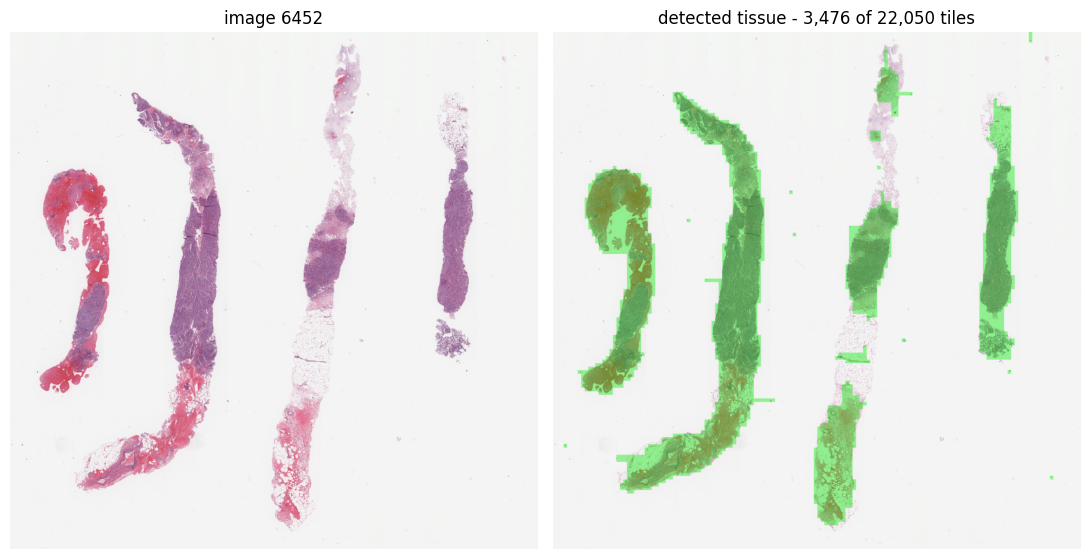

In [9]:
qc_id = cohort["image_id"].iloc[0]
qc_thumb = thumbnails[qc_id]["thumbnail"]
qc_mask = tissue[qc_id]["mask"]

# Paint the tile mask back onto the thumbnail at thumbnail resolution.
px = round(PATCH_SIZE * MPP / 7.0)
painted = np.kron(qc_mask, np.ones((px, px), dtype=bool))[: qc_thumb.shape[0], : qc_thumb.shape[1]]

fig, axes = plt.subplots(1, 2, figsize=(11, 6))
axes[0].imshow(qc_thumb)
axes[0].set_title(f"image {qc_id}")
axes[1].imshow(utils.overlay_mask(qc_thumb, painted))
axes[1].set_title(f"detected tissue - {qc_mask.sum():,} of {qc_mask.size:,} tiles")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

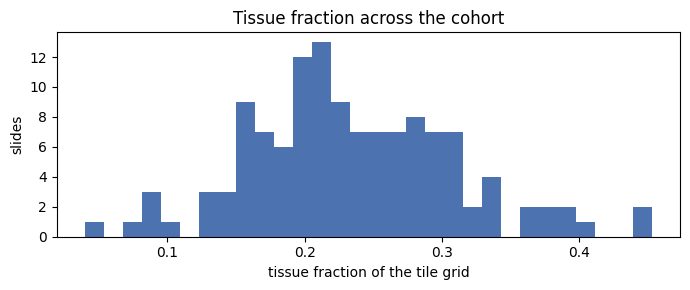

Least and most tissue - worth an eyeball in the viewer:
 image_id       name  tissue_fraction
     6663 062_HE.svs         0.040378
     6652 122_HE.svs         0.079253
     6461 110_HE.svs         0.087989
 image_id       name  tissue_fraction
     6464 086_HE.svs         0.452548
     6546 939_HE.svs         0.446554
     6466 905_HE.svs         0.401112


In [10]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(kept / total, bins=30, color="#4C72B0")
ax.set_xlabel("tissue fraction of the tile grid")
ax.set_ylabel("slides")
ax.set_title("Tissue fraction across the cohort")
plt.tight_layout()
plt.show()

worst = cohort.assign(tissue_fraction=[tissue[i]["mask"].mean() for i in cohort["image_id"]])
print("Least and most tissue - worth an eyeball in the viewer:")
print(worst.nsmallest(3, "tissue_fraction")[["image_id", "name", "tissue_fraction"]].to_string(index=False))
print(worst.nlargest(3, "tissue_fraction")[["image_id", "name", "tissue_fraction"]].to_string(index=False))

## 4. Embed the tissue with H-optimus-1

`embed_roi` takes one image at a time, so this is one job per slide. We submit all of them
first and only then start polling, so the jobs run concurrently on the service rather than
one after another.

The ticket ids are cached. If this notebook is interrupted, re-running picks up the existing
jobs instead of resubmitting them.

In [11]:
def submit_all():
    tickets = {}
    for image_id in tqdm(image_ids, desc="submitting"):
        tickets[str(image_id)] = client.embed_roi(
            image_id=image_id, regions=tissue[image_id]["regions"], mpp=MPP, model=MODEL
        )
    return tickets


tickets = cached("tickets.json", submit_all)
print(f"{len(tickets)} embedding jobs")

126 embedding jobs


Each completed job is reduced straight to what training needs — a `(n_tiles, dim)` matrix
plus the grid coordinate of each tile — and written to `data/impress/bags/`. Keeping the
bags rather than the raw safetensors means the training cells below re-run in seconds.

The service occasionally returns marginally fewer tiles than were requested (edge tiles, or
regions that turn out to be blank), so tiles are indexed by the grid keys that come back
rather than by the tissue mask.

In [12]:
def bag_path(image_id):
    return os.path.join(BAG_DIR, f"{image_id}.npz")


failed = []
for image_id in tqdm(image_ids, desc="fetching embeddings"):
    if os.path.exists(bag_path(image_id)):
        continue
    result = client.get_embeddings(tickets[str(image_id)], polling_interval_seconds=30)
    if result is None or not result["images"]:
        failed.append(image_id)
        continue

    image = result["images"][0]
    keys, coords = utils.parse(image["embedding"])
    np.savez_compressed(
        bag_path(image_id),
        # float16 halves the cache on disk; the values are cast back for training.
        embeddings=utils.stack_embedding(image["embedding"], keys).astype(np.float16),
        coords=np.array([coords[k] for k in keys], dtype=np.int16),
        grid=np.array([image["grid_rows"], image["grid_cols"]], dtype=np.int16),
    )

if failed:
    print(f"WARNING: {len(failed)} slides failed and are excluded: {failed}")
cohort = cohort[~cohort["image_id"].isin(failed)]
print(f"{len(cohort)} slides available for training")

fetching embeddings:   0%|          | 0/126 [00:00<?, ?it/s]

126 slides available for training


In [13]:
bags = {}
for image_id in tqdm(cohort["image_id"], desc="loading bags"):
    with np.load(bag_path(image_id)) as z:
        bags[image_id] = {"embeddings": z["embeddings"], "coords": z["coords"], "grid": tuple(z["grid"])}

sizes = np.array([len(b["embeddings"]) for b in bags.values()])
print(f"{len(bags)} bags, {sizes.sum():,} tiles total")
print(f"Tiles per slide: median {int(np.median(sizes)):,}, range {sizes.min():,}-{sizes.max():,}")
print(f"Embedding dim:   {bags[cohort['image_id'].iloc[0]]['embeddings'].shape[1]}")

loading bags:   0%|          | 0/126 [00:00<?, ?it/s]

126 bags, 721,031 tiles total
Tiles per slide: median 4,654, range 418-29,224
Embedding dim:   1536


## 5. Do the embeddings capture anything? A quick PCA

Before training, a sanity check borrowed from the
[Bioptimus H-optimus-1 quickstart](https://github.com/bioptimus/h1-jumpstart): project one
slide's tiles onto their first principal components and map those components back onto the
slide. If the leading components trace recognisable tissue architecture rather than noise,
the embeddings are carrying morphology.

/Users/coreychivers/Library/Caches/pypoetry/virtualenvs/proscia-ai-tools-9aSb50xl-py3.12/lib/python3.12/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/coreychivers/Library/Caches/pypoetry/virtualenvs/proscia-ai-tools-9aSb50xl-py3.12/lib/python3.12/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/coreychivers/Library/Caches/pypoetry/virtualenvs/proscia-ai-tools-9aSb50xl-py3.12/lib/python3.12/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/coreychivers/Library/Caches/pypoetry/virtualenvs/proscia-ai-tools-9aSb50xl-py3.12/lib/python3.12/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/coreychivers/Library/Caches/pypoetry/virtualenvs/proscia-ai-tools-9aSb50xl-py3.12/lib/

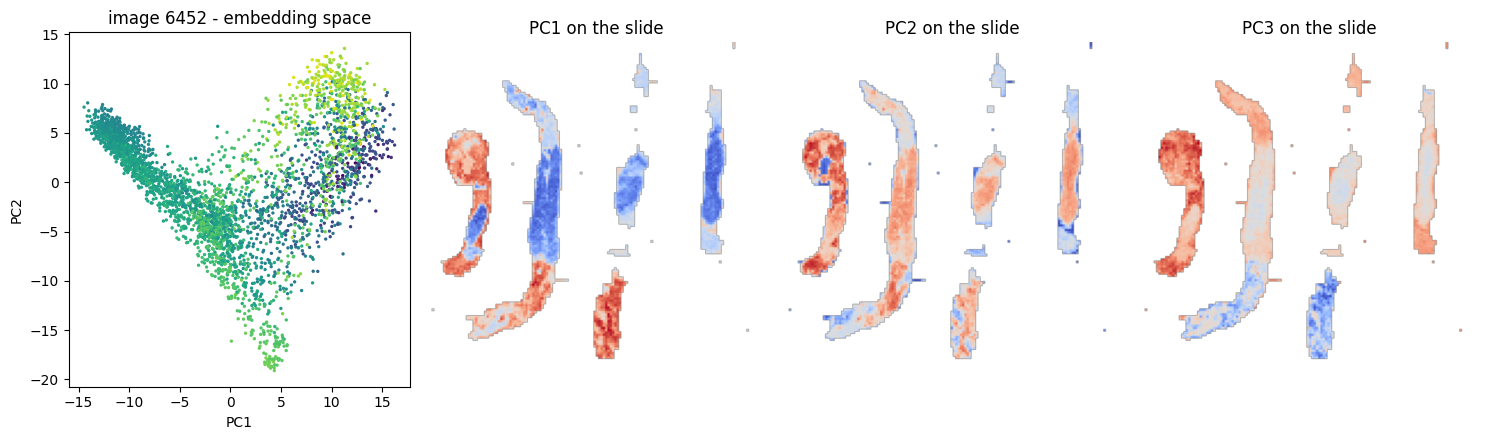

In [14]:
qc_bag = bags[qc_id]
scores = PCA(n_components=3, random_state=SEED).fit_transform(qc_bag["embeddings"].astype(np.float32))

fig = plt.figure(figsize=(15, 4.5))
ax = fig.add_subplot(1, 4, 1)
ax.scatter(scores[:, 0], scores[:, 1], c=scores[:, 2], s=2, cmap="viridis")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"image {qc_id} - embedding space")

rows, cols = qc_bag["coords"][:, 0], qc_bag["coords"][:, 1]
for i in range(3):
    ax = fig.add_subplot(1, 4, i + 2)
    grid = np.full(qc_bag["grid"], np.nan)
    grid[rows, cols] = scores[:, i]
    ax.imshow(grid, cmap="coolwarm")
    ax.set_title(f"PC{i + 1} on the slide")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. The MIL model

A gated-attention MIL head, following
[Ilse et al. (2018)](https://arxiv.org/abs/1802.04712). It is deliberately small — the
foundation model has already done the representation learning, and with 126 slides anything
larger would simply memorise them.

For each tile the network computes an attention weight; the weights are softmaxed across the
bag and used to pool tile features into a single slide feature, which a linear layer turns
into one logit. Because the pooling is a weighted average, the attention weights are
directly interpretable as "how much did this tile contribute to the slide-level call" — and
that is exactly the map we push back to Concentriq.

In [15]:
class GatedAttentionMIL(nn.Module):
    def __init__(self, in_dim, hidden=256, attn_dim=128, dropout=0.25):
        super().__init__()
        self.project = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout))
        self.attn_v = nn.Sequential(nn.Linear(hidden, attn_dim), nn.Tanh())
        self.attn_u = nn.Sequential(nn.Linear(hidden, attn_dim), nn.Sigmoid())
        self.attn_w = nn.Linear(attn_dim, 1)
        self.classify = nn.Linear(hidden, 1)

    def forward(self, bag):
        """bag: (n_tiles, in_dim) -> (slide logit, per-tile attention)."""
        h = self.project(bag)
        attention = torch.softmax(self.attn_w(self.attn_v(h) * self.attn_u(h)), dim=0)
        pooled = (attention * h).sum(dim=0)
        return self.classify(pooled).squeeze(), attention.squeeze(-1)

### Training a single fold

Bags have thousands of tiles and vary in size, so there is no batching: one slide is one
step. During training each bag is randomly subsampled, which keeps steps cheap and acts as
augmentation; at inference the whole bag is used. The loss is weighted by the class ratio,
since only ~29% of slides are positive.

In [16]:
TILES_PER_STEP = 2048
EPOCHS = 25
LR = 2e-4


def to_tensor(image_id, subsample=None):
    tiles = bags[image_id]["embeddings"]
    if subsample and len(tiles) > subsample:
        tiles = tiles[rng.choice(len(tiles), subsample, replace=False)]
    return torch.from_numpy(tiles.astype(np.float32)).to(device)


@torch.no_grad()
def predict(model, ids):
    model.eval()
    logits, attentions = [], {}
    for image_id in ids:
        logit, attention = model(to_tensor(image_id))
        logits.append(logit.item())
        attentions[image_id] = attention.cpu().numpy()
    return np.array(logits), attentions


def train_fold(train_ids, train_labels):
    model = GatedAttentionMIL(EMBEDDING_DIM).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    pos_weight = torch.tensor([(train_labels == 0).sum() / max((train_labels == 1).sum(), 1)]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    order = np.arange(len(train_ids))
    for _ in range(EPOCHS):
        model.train()
        rng.shuffle(order)
        for i in order:
            logit, _ = model(to_tensor(train_ids[i], subsample=TILES_PER_STEP))
            loss = criterion(logit.unsqueeze(0), torch.tensor([float(train_labels[i])], device=device))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model

## 7. Cross-validation

With 126 slides there is no room for a held-out test set that would mean anything, so we use
5-fold stratified cross-validation and report out-of-fold predictions: every slide is scored
by a model that never saw it. Each patient contributes exactly one H&E slide, so splitting by
slide is already splitting by patient — asserted below, because getting that wrong is the
classic way to manufacture a good-looking AUC.

In [17]:
assert cohort["patient"].is_unique, "expected one H&E slide per patient"

ids = cohort["image_id"].to_numpy()
labels = cohort["label"].to_numpy()

oof_logits = np.zeros(len(ids))
oof_attention = {}
fold_scores = []

# 5 folds, unless a rehearsal subset has fewer slides than that in its smaller class.
n_splits = min(5, int(labels.sum()), int((labels == 0).sum()))

for fold, (train_idx, test_idx) in enumerate(
    StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED).split(ids, labels), start=1
):
    model = train_fold(ids[train_idx], labels[train_idx])
    logits, attentions = predict(model, ids[test_idx])
    oof_logits[test_idx] = logits
    oof_attention.update(attentions)
    auc = roc_auc_score(labels[test_idx], logits)
    fold_scores.append(auc)
    print(f"fold {fold}: n_test={len(test_idx)}  positives={labels[test_idx].sum()}  AUC={auc:.3f}")

print(f"\nMean fold AUC: {np.mean(fold_scores):.3f} +/- {np.std(fold_scores):.3f}")

fold 1: n_test=26  positives=8  AUC=0.722


fold 2: n_test=25  positives=8  AUC=0.904


fold 3: n_test=25  positives=7  AUC=0.881


fold 4: n_test=25  positives=7  AUC=0.865


fold 5: n_test=25  positives=7  AUC=0.881

Mean fold AUC: 0.851 +/- 0.065


## 8. How well did it do?

The pooled out-of-fold ROC below is the honest summary. Read it with the sample size in
mind: with ~37 positives, the 95% confidence interval on the AUC is wide, and the difference
between an AUC of 0.65 and 0.75 here is not much more than which slides landed in which
fold. Published H&E-to-PD-L1 models in breast reach ~0.8 on cohorts an order of magnitude
larger.

In [18]:
probabilities = 1 / (1 + np.exp(-oof_logits))
auc = roc_auc_score(labels, probabilities)
ap = average_precision_score(labels, probabilities)
fpr, tpr, thresholds = roc_curve(labels, probabilities)

# Youden's J: the threshold that maximises sensitivity + specificity.
cutoff = thresholds[np.argmax(tpr - fpr)]
metrics = utils.calculate_boolean_metrics(gt=labels, pred=(probabilities >= cutoff).astype(int))

print(f"Out-of-fold ROC-AUC:      {auc:.3f}")
print(f"Out-of-fold PR-AUC:       {ap:.3f}  (baseline = {labels.mean():.3f}, the positive rate)")
print(f"\nAt the Youden threshold ({cutoff:.3f}):")
print(f"  sensitivity {metrics['sen']:.2f}   specificity {metrics['spe']:.2f}")
print(f"  PPV         {metrics['ppv']:.2f}   NPV         {metrics['npv']:.2f}")
print(f"  confusion matrix [[tn fp], [fn tp]]:\n{metrics['cm']}")

Out-of-fold ROC-AUC:      0.836
Out-of-fold PR-AUC:       0.682  (baseline = 0.294, the positive rate)

At the Youden threshold (0.080):
  sensitivity 0.81   specificity 0.79
  PPV         0.61   NPV         0.91
  confusion matrix [[tn fp], [fn tp]]:
[[70 19]
 [ 7 30]]


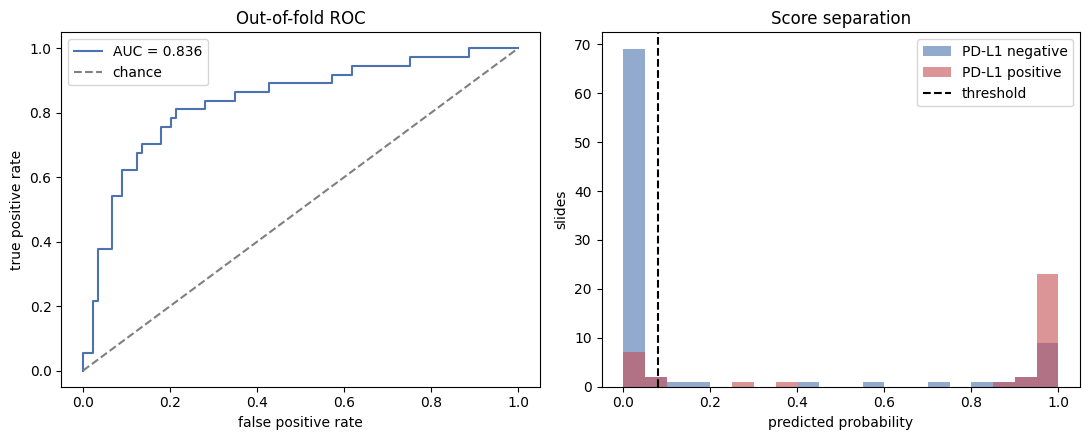

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, tpr, color="#4C72B0", label=f"AUC = {auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="chance")
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].set_title("Out-of-fold ROC")
axes[0].legend()

for label, name, color in [(0, "PD-L1 negative", "#4C72B0"), (1, "PD-L1 positive", "#C44E52")]:
    axes[1].hist(probabilities[labels == label], bins=20, alpha=0.6, label=name, color=color)
axes[1].axvline(cutoff, color="black", linestyle="--", label="threshold")
axes[1].set_xlabel("predicted probability")
axes[1].set_ylabel("slides")
axes[1].set_title("Score separation")
axes[1].legend()
plt.tight_layout()
plt.show()

### Is it learning PD-L1, or just the disease subtype?

This is the first question a pathologist will ask, and the cohort makes it a fair one. PD-L1
positivity is far more common in TNBC than in HER2+ in IMPRESS, and the two subtypes are
themselves distinguishable on H&E. A model could therefore score well by recognising subtype
and learning nothing about PD-L1 at all.

The check below asks two things: how far subtype alone gets you, and how the model does
*within* each subtype, where subtype is held constant and cannot be the explanation. The
within-subtype numbers are the honest read. The HER2+ figure rests on very few positives, so
treat it as indicative at best.

In [ ]:
subtype_positive = (cohort["IMPRESS cohort"] == "TNBC").astype(int)
print(f"Subtype alone (TNBC = positive):  AUC = {roc_auc_score(labels, subtype_positive):.3f}")
print(f"The MIL model:                    AUC = {auc:.3f}")

print("\nOut-of-fold AUC within each subtype:")
analysis = cohort.assign(probability=probabilities, y=labels)
for name, group in analysis.groupby("IMPRESS cohort"):
    if group["y"].nunique() < 2:
        continue
    print(f"  {name:<6} n={len(group):>3}  positives={int(group['y'].sum()):>3}  "
          f"AUC = {roc_auc_score(group['y'], group['probability']):.3f}")

Subtype alone (TNBC = positive):  AUC = 0.734
The MIL model:                    AUC = 0.836

Out-of-fold AUC within each subtype:
  HER2+  n= 62  positives=  6  AUC = 0.738
  TNBC   n= 64  positives= 31  AUC = 0.804


## 9. Where was the model looking?

The attention weights live on the embedding tile grid, which is exactly the shape
`insert_heatmap_overlay` wants — Concentriq stretches the overlay across the slide, so no
resampling is needed on our side. Tiles with no tissue keep an attention of zero and
`utils.create_overlay` renders those fully transparent.

Attention is normalised per slide to its own maximum: it says *where on this slide* the
model looked, and the values are not comparable between slides.

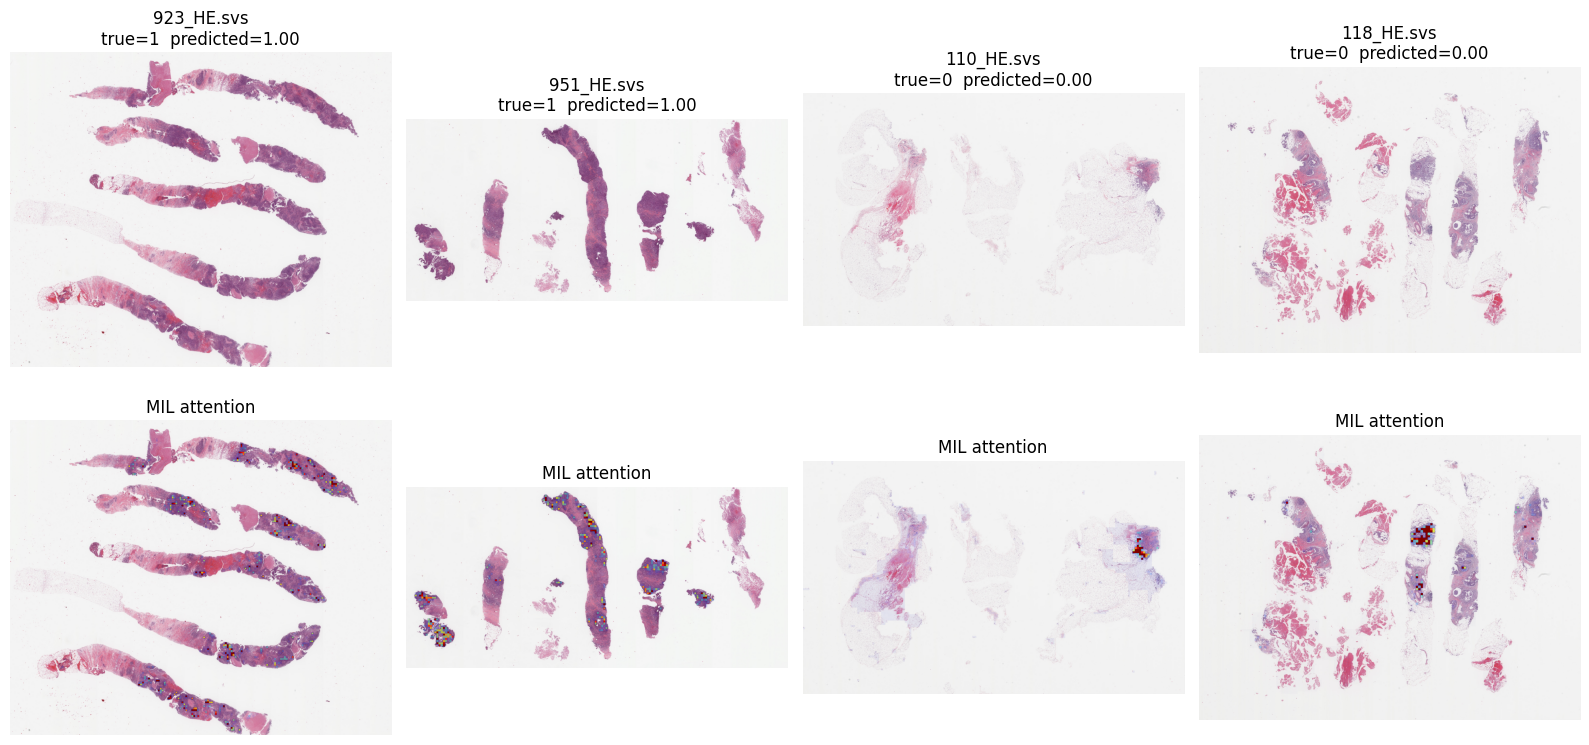

In [21]:
def attention_grid(image_id):
    bag = bags[image_id]
    grid = np.zeros(bag["grid"])
    grid[bag["coords"][:, 0], bag["coords"][:, 1]] = oof_attention[image_id]
    return grid / grid.max()


scored = cohort.assign(probability=probabilities).sort_values("probability")
examples = pd.concat([scored.tail(2), scored.head(2)])  # two most and two least confident

fig, axes = plt.subplots(2, len(examples), figsize=(4 * len(examples), 8))
for ax_top, ax_bottom, (_, slide) in zip(axes[0], axes[1], examples.iterrows(), strict=False):
    thumb = thumbnails[slide["image_id"]]["thumbnail"]
    grid = attention_grid(slide["image_id"])
    ax_top.imshow(thumb)
    ax_top.set_title(f"{slide['name']}\ntrue={slide['label']}  predicted={slide['probability']:.2f}")
    attention = np.kron(grid, np.ones((px, px)))[: thumb.shape[0], : thumb.shape[1]]
    # Softmax attention is sharply peaked, so the raw weights leave only a few opaque
    # dots. For display, saturate the top ~1% of tissue tiles and apply a mild gamma so
    # mid-attention tissue reads as regions; true zeros (glass) stay fully transparent.
    hot = attention[attention > 0]
    display = np.clip(attention / np.percentile(hot, 99), 0, 1) ** 0.7 if hot.size else attention
    overlay = plt.cm.jet(display)
    overlay[..., 3] = display
    ax_bottom.imshow(thumb)
    ax_bottom.imshow(overlay)
    ax_bottom.set_title("MIL attention")
    ax_top.axis("off")
    ax_bottom.axis("off")
plt.tight_layout()
plt.show()

### Push the overlays into Concentriq

The same arrays go back to the platform, where a pathologist can pan and zoom them against
the slide at full resolution — which is the only way to judge whether the attention is
landing on anything meaningful. For each H&E slide we also print the link to the matched IHC
slide, so the attention map can be compared against the stain the label came from.

In [22]:
RESULT_NAME = f"H-optimus-1 MIL - {LABEL_FIELD}"

for _, slide in examples.iterrows():
    cls.insert_heatmap_overlay(
        image_id=int(slide["image_id"]), heatmap=attention_grid(slide["image_id"]), result_name=RESULT_NAME
    )
    print(f"{slide['name']}  true={slide['label']}  predicted={slide['probability']:.2f}")
    print(f"  H&E + attention: {creds['url']}/images/{int(slide['image_id'])}")
    if pd.notna(slide["ihc_image_id"]):
        print(f"  matched IHC:     {creds['url']}/images/{int(slide['ihc_image_id'])}")

923_HE.svs  true=1  predicted=1.00
  H&E + attention: https://main.concentriq.development.proscia.com/images/6567
  matched IHC:     https://main.concentriq.development.proscia.com/images/6673


951_HE.svs  true=1  predicted=1.00
  H&E + attention: https://main.concentriq.development.proscia.com/images/6579
  matched IHC:     https://main.concentriq.development.proscia.com/images/6543


110_HE.svs  true=0  predicted=0.00
  H&E + attention: https://main.concentriq.development.proscia.com/images/6461
  matched IHC:     https://main.concentriq.development.proscia.com/images/6641


118_HE.svs  true=0  predicted=0.00
  H&E + attention: https://main.concentriq.development.proscia.com/images/6612
  matched IHC:     https://main.concentriq.development.proscia.com/images/6669


## 10. Where to take this next

- **Other endpoints, same embeddings.** The IMPRESS metadata also carries PD-L1 stroma
  positivity, CD8 and CD163 positivity, pCR and RCB. Point `LABEL_FIELD` at any of them and
  re-run from section 6 — the embeddings are already cached, so it costs minutes, not hours.
  `IMPRESS PD-L1 stroma +` is the better-balanced label if you want an easier demonstration.
- **Stratify by disease.** HER2+ and TNBC behave differently; with more slides, training
  per-cohort models is the obvious next split.
- **More data before more model.** At n=126 the ceiling is the cohort, not the architecture.
  Adding slides will move the number; adding layers will not.
- **Into the platform.** A trained tile-level classifier can be exported to ONNX and run
  inside a No-Code Analysis pipeline as an `embedding_classifier` step, which turns a
  notebook result into something clinical users can run themselves.